In [6]:
import zipfile
import os

# Path to the ZIP file (replace with the actual path)
zip_file_path = 'Project.zip'  # If it's in the same folder as the notebook

# Destination folder where you want to extract the files
extract_path = 'Project'  # You can specify any folder here

# Create the folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Files extracted to {extract_path}')


Files extracted to Project


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import tensorflow as tf
import keras
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential, load_model
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
from keras.utils import to_categorical

In [3]:
image_shape = (227,227,3)
np.random.seed(1000)
model = Sequential()

In [4]:
from PIL import Image
import os

In [5]:
train_dataset = pd.read_csv(r'C:\Users\ASWATHY.I\Project\Project\Train.csv')

In [6]:
train_dataset.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [7]:
test_dataset = pd.read_csv(r'C:\Users\ASWATHY.I\Project\Project\Test.csv')

In [8]:
test_dataset.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [9]:
data = []
labels = []

classes = 43

cur_path = os.getcwd()
cur_path

'C:\\Users\\ASWATHY.I'

In [10]:
new_path = r'C:\Users\ASWATHY.I\Project\Project'
os.chdir(new_path)

# Verify the change
cur_path = os.getcwd()
print(f"New working directory: {cur_path}")

New working directory: C:\Users\ASWATHY.I\Project\Project


In [11]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
import tensorflow as tf
from tensorflow.keras.optimizers import SGD

In [12]:
# preprocessing function
def preprocess_image(image):
    if image.mode != 'RGB':
        image = image.convert('RGB')
    image = image.resize((227, 227))
    image = np.array(image).astype('float32') / 255.0
    return image

In [13]:
# Data generator to load and preprocess images
def load_and_preprocess_images(image_paths, labels, batch_size=64):
    while True:  # Loop indefinitely for training
        data = []
        for i, image_path in enumerate(image_paths):
            try:
                image = Image.open(image_path)
                image = preprocess_image(image)
                data.append(image)
                if len(data) >= batch_size:
                    yield np.array(data), to_categorical(np.array(labels[i-batch_size+1:i+1]), num_classes=43)
                    data = []  # Reset data after yielding

            except Exception as e:
                print(f"Error loading image {image_path}: {e}")

In [14]:
# Parameters
classes = 43  # Number of class folders
batch_size = 64  
epochs = 15

In [15]:
# Collect all image paths and labels
all_image_paths = []
all_labels = []

for i in range(classes):
    path = os.path.join(r'C:\Users\ASWATHY.I\Project\Project\Train', str(i))
    if not os.path.isdir(path):
        print(f"Directory not found: {path}")
        continue
    images = os.listdir(path)
    for image_name in images:
        all_image_paths.append(os.path.join(path, image_name))
        all_labels.append(i)

# Convert labels to NumPy array
all_labels = np.array(all_labels)

# Split into training and validation sets
X_train_paths, X_val_paths, y_train, y_val = train_test_split(all_image_paths, all_labels, test_size=0.2, random_state=42)

In [16]:

# Create the model
alexnet_model = Sequential()

# 1st Convolution Layer
alexnet_model.add(Conv2D(filters=96, input_shape=image_shape, kernel_size=(11, 11), strides=(4, 4), padding='valid'))
alexnet_model.add(Activation('relu'))

# Max Pooling
alexnet_model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# 2nd Convolution Layer
alexnet_model.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), padding='valid'))
alexnet_model.add(Activation('relu'))

# Max Pooling
alexnet_model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

# 3rd Convolution Layer
alexnet_model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), padding='valid'))
alexnet_model.add(Activation('relu'))

# 4th Convolution Layer
alexnet_model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), padding='valid'))
alexnet_model.add(Activation('relu'))

# 5th Convolution Layer
alexnet_model.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), padding='valid'))
alexnet_model.add(Activation('relu'))

# Max Pooling
alexnet_model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

# Flatten
alexnet_model.add(Flatten())

# 1st Fully Connected Layer
alexnet_model.add(Dense(4096))
alexnet_model.add(Activation('relu'))

# Dropout layer
alexnet_model.add(Dropout(0.4))

# 2nd Fully Connected Layer
alexnet_model.add(Dense(4096))
alexnet_model.add(Activation('relu'))

# Output Layer
alexnet_model.add(Dense(classes))
alexnet_model.add(Activation('softmax'))

# Compile the model with SGD optimizer (with momentum and weight decay)
sgd = SGD(learning_rate=0.01, momentum=0.9, decay=0.0005)  # Weight decay is applied via 'decay' parameter
alexnet_model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer=sgd, metrics=['accuracy'])



In [17]:
# Train the alexnet_model using the data generator for training
train_generator = load_and_preprocess_images(X_train_paths, y_train, batch_size)
val_generator = load_and_preprocess_images(X_val_paths, y_val, batch_size)

# Calculate steps per epoch for training and validation
steps_per_epoch = len(X_train_paths) // batch_size
validation_steps = len(X_val_paths) // batch_size

# Train the model
alexnet_history = alexnet_model.fit(train_generator,
                    steps_per_epoch=steps_per_epoch,
                    validation_data=val_generator,
                    validation_steps=validation_steps,
                    epochs=epochs)

Epoch 1/15
490/490 [==============================] - 741s 2s/step - loss: 2.3146 - accuracy: 0.3765 - val_loss: 0.3824 - val_accuracy: 0.8901
Epoch 2/15
490/490 [==============================] - 721s 1s/step - loss: 0.1855 - accuracy: 0.9486 - val_loss: 0.0684 - val_accuracy: 0.9803
Epoch 3/15
490/490 [==============================] - 721s 1s/step - loss: 0.0451 - accuracy: 0.9875 - val_loss: 0.0250 - val_accuracy: 0.9941
Epoch 4/15
490/490 [==============================] - 844s 2s/step - loss: 0.0196 - accuracy: 0.9947 - val_loss: 0.0227 - val_accuracy: 0.9949
Epoch 5/15
490/490 [==============================] - 784s 2s/step - loss: 0.0070 - accuracy: 0.9984 - val_loss: 0.0179 - val_accuracy: 0.9960
Epoch 6/15
490/490 [==============================] - 746s 2s/step - loss: 0.0041 - accuracy: 0.9991 - val_loss: 0.0172 - val_accuracy: 0.9964
Epoch 7/15
490/490 [==============================] - 681s 1s/step - loss: 0.0045 - accuracy: 0.9991 - val_loss: 0.0190 - val_accuracy: 0.9955

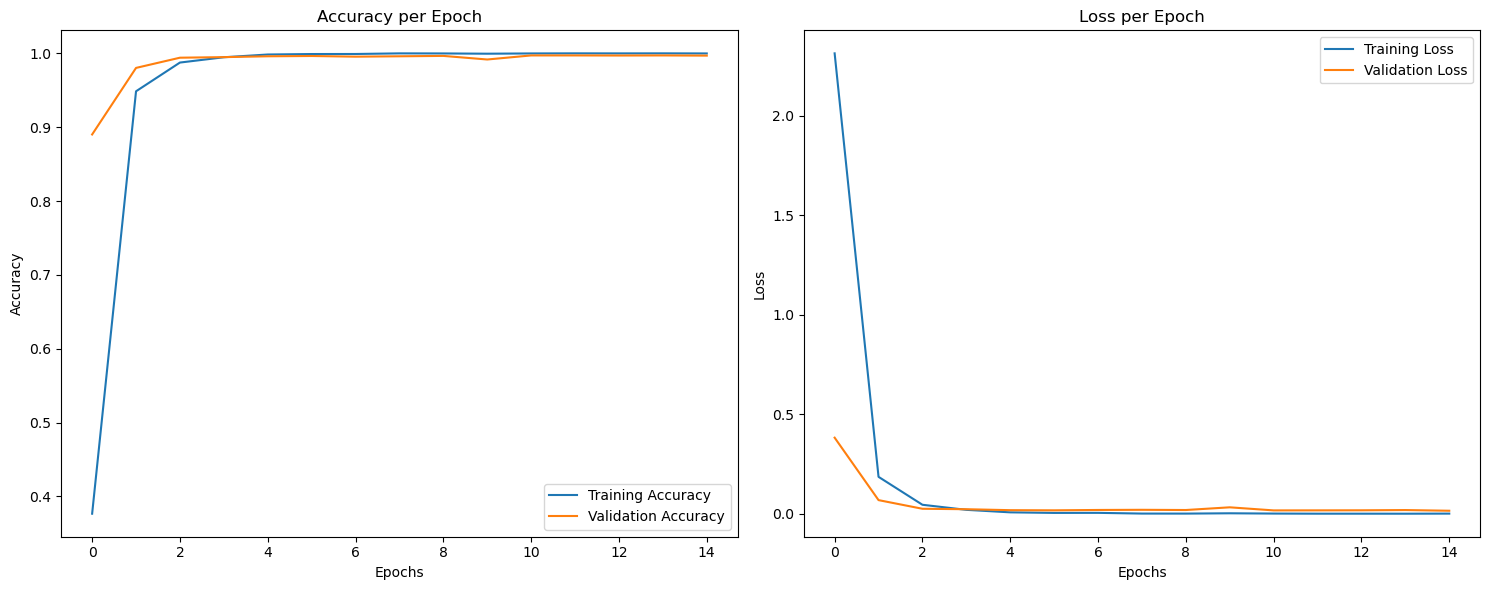

In [18]:
# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Plotting Accuracy
axs[0].plot(alexnet_history.history['accuracy'], label='Training Accuracy')
axs[0].plot(alexnet_history.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_title('Accuracy per Epoch')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

# Plotting Loss
axs[1].plot(alexnet_history.history['loss'], label='Training Loss')
axs[1].plot(alexnet_history.history['val_loss'], label='Validation Loss')
axs[1].set_title('Loss per Epoch')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()

# Adjust layout
plt.tight_layout()
plt.show()


In [19]:
import os
import numpy as np
from sklearn.metrics import accuracy_score
import pandas as pd
from PIL import Image

# Load the CSV file
y_test = pd.read_csv(r'C:\Users\ASWATHY.I\Project\Project\Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values

data = []
valid_labels = []

# Directory where the images are located
image_directory = r'C:\Users\ASWATHY.I\Project\Project'

for img, label in zip(imgs, labels):
    # Full path of the image
    image_path = os.path.join(image_directory, img)
    
    # Check if the image file exists
    if not os.path.exists(image_path):
        print(f"File not found: {image_path}. Stopping process.")
        break  # Stop processing if the file is not found
    
    try:
        image = Image.open(image_path)
        image = preprocess_image(image)
        data.append(np.array(image))
        valid_labels.append(label)  # Only append the label for valid images
    except Exception as e:
        print(f"Error loading image {img}: {e}")
        break

# Convert data to numpy arrays
X_test = np.array(data)
valid_labels = np.array(valid_labels)


File not found: C:\Users\ASWATHY.I\Project\Project\Test/02788.png. Stopping process.


In [22]:
print(X_test.shape)  # Should match the expected input shape of the model

(2788, 227, 227, 3)


In [25]:
# Predict class probabilities using AlexNet model
pred_probabilities = alexnet_model.predict(X_test)

# Convert probabilities to predicted classes
pred = np.argmax(pred_probabilities, axis=1)

print(accuracy_score(valid_labels, pred))

#true = np.argmax(y_test, axis=1)

# Calculate accuracy
#accuracy = accuracy_score(true, pred)
#print(f"AlexNet Accuracy: {accuracy * 100:.2f}%")

# Save accuracy to CSV
#save_accuracy('AlexNet', accuracy * 100)


88/88 [==============================] - 16s 176ms/step
0.9573170731707317


In [28]:
alexnet_model.save(r'Project/alexnet_model_RTSR.h5')

In [35]:
import os
import csv

# Define your model metrics
model_name = 'AlexNet'

# Define the CSV file path
filename = 'model_accuracies.csv'

# Check if the file already exists
file_exists = os.path.isfile(filename)

# Open the file in append mode and write the metrics
with open(filename, mode='a', newline='') as file:
    writer = csv.writer(file)
    
    if not file_exists:
        # Write the header if the file doesn't exist yet
        writer.writerow(['Model', 'Test Accuracy', 'Test Loss'])
    
    # Write the model's metrics
    writer.writerow([model_name, alexnet_history.history['val_accuracy'][-1], alexnet_history.history['val_loss'][-1]])

print(f"Metrics saved to {filename}")


Metrics saved to model_accuracies.csv
